# Notebook 3 — Full Depolarizing-Noise Sweep, Pseudo-Thresholds & Figures

This notebook contains the full simulation engine (`simulate.py`), runs the 12-point physical-error-rate sweep for both codes at 200,000 shots per point (`run_full.py`), solves for each code's pseudo-threshold p\*, and generates the three figures used in the paper (`make_figures.py`).

**Methodology summary**
- *Bit-flip code*: exact enumeration over all 4³ = 64 per-qubit Pauli assignments (closed-form-equivalent) plus vectorized Monte Carlo sampling.
- *Surface code*: vectorized Aaronson–Gottesman-consistent stabilizer-formalism computation (Pauli-frame propagation + exact minimum-weight lookup decoding), both as full 4⁹ = 262,144-pattern exact enumeration and as Monte Carlo sampling.
- Pseudo-thresholds p\* found via root-finding on `P_L(p) − p`.
- Two logical-failure criteria are computed for the bit-flip code: the *bit-observable* metric (Eq. 9 in the paper, used as the primary reported metric) and the *full quantum-state-protection* metric (Eq. 9′, a secondary diagnostic showing the code cannot protect phase information).

## 3.1 — Simulation engine (`simulate.py`)

In [1]:
import numpy as np
import itertools, json

rng = np.random.default_rng(20260719)

# ---------------------------------------------------------------------
# 1. THREE-QUBIT BIT-FLIP CODE — exact enumeration (4^3 = 64 configs)
#    Pauli per qubit: I (1-p), X (p/3), Y (p/3), Z (p/3)
#    x-component present iff error in {X,Y}; z-component present iff error in {Z,Y}
#    Logical X-bar failure iff weight(x-components) >= 2  (majority-vote miscorrects)
#    Logical Z-bar failure iff weight(z-components) is odd (1 or 3)  (undetectable phase leakage)
#    Overall logical failure iff either condition holds.
# ---------------------------------------------------------------------
paulis = ['I', 'X', 'Y', 'Z']
xcomp = {'I': 0, 'X': 1, 'Y': 1, 'Z': 0}
zcomp = {'I': 0, 'X': 0, 'Y': 1, 'Z': 1}

# PRIMARY reported metric: "bit-observable" logical error rate. The 3-qubit code's
# stabilizers (Z0Z1, Z1Z2) and majority-vote decoder only ever act on the X-component of
# the error; Z-type components are invisible to this code by construction. This is the
# quantity Eq. (7)-(8) generalizes to full depolarizing noise: each qubit carries an
# X-component (from an X or Y error) with probability q = 2p/3.
def bitflip_PL_exact(p):
    q = 2 * p / 3
    return 3 * q**2 * (1 - q) + q**3

def bitflip_PL_montecarlo(p, nshots, rng):
    probs = [1 - p, p/3, p/3, p/3]
    draws = rng.choice(4, size=(nshots, 3), p=probs)  # 0=I,1=X,2=Y,3=Z
    xw = ((draws == 1) | (draws == 2)).sum(axis=1)
    fail = (xw >= 2)
    k = int(fail.sum())
    return k / nshots, k

# SECONDARY diagnostic: full quantum-state-protection logical error rate, which also
# counts the (always-undetected) phase-leakage failures from Z/Y components. Used only
# to test whether the code can serve as a general-purpose QEC code under full
# depolarizing noise (Section 7.2 discussion), not as the primary Table 2 metric.
def bitflip_PL_full_exact(p):
    total = 0.0
    prob = {'I': 1 - p, 'X': p/3, 'Y': p/3, 'Z': p/3}
    for combo in itertools.product(paulis, repeat=3):
        pr = 1.0
        for e in combo:
            pr *= prob[e]
        xw = sum(xcomp[e] for e in combo)
        zw = sum(zcomp[e] for e in combo)
        fail = (xw >= 2) or (zw % 2 == 1)
        if fail:
            total += pr
    return total

# pure-X-only theoretical curve (Eq 8 context)
def bitflip_PL_Xonly(p):
    return 3*p**2*(1-p) + p**3

# ---------------------------------------------------------------------
# 2. DISTANCE-3 SURFACE CODE — Monte Carlo with exact min-weight lookup decoder
# ---------------------------------------------------------------------
data = np.load("surface_code_structure.npz")
Hx, Hz, Lx, Lz = data['Hx'], data['Hz'], data['Lx'], data['Lz']
n = int(data['n_data'])

def build_lookup(H):
    """H: (m, n) parity check. Returns dict: syndrome(int) -> correction vector (min weight)."""
    m = H.shape[0]
    table = {}
    weight_table = {}
    for bits in itertools.product([0, 1], repeat=n):
        e = np.array(bits)
        syn = tuple((H @ e) % 2)
        syn_int = int(''.join(map(str, syn)), 2) if m > 0 else 0
        w = e.sum()
        if syn_int not in table or w < weight_table[syn_int]:
            table[syn_int] = e.copy()
            weight_table[syn_int] = w
    return table

lut_z = build_lookup(Hz)   # syndrome from Z-stabilizers -> correction for X errors
lut_x = build_lookup(Hx)   # syndrome from X-stabilizers -> correction for Z errors

def syn_to_int(bits):
    if len(bits) == 0:
        return 0
    out = 0
    for b in bits:
        out = (out << 1) | int(b)
    return out

def surface_PL_montecarlo(p, nshots, rng):
    probs = [1 - p, p/3, p/3, p/3]
    draws = rng.choice(4, size=(nshots, n), p=probs)  # 0=I,1=X,2=Y,3=Z
    ex = ((draws == 1) | (draws == 2)).astype(int)  # X-component per qubit
    ez = ((draws == 3) | (draws == 2)).astype(int)  # Z-component per qubit

    synZ = (ex @ Hz.T) % 2   # detects X errors  (nshots, n_Zstab)
    synX = (ez @ Hx.T) % 2   # detects Z errors  (nshots, n_Xstab)

    fail = np.zeros(nshots, dtype=bool)
    # vectorize decode via precomputed table indexed by integer syndrome
    # build syndrome->correction arrays
    nZ = Hz.shape[0]
    nX = Hx.shape[0]
    # correction lookup as arrays for speed
    max_synZ = 2**nZ
    max_synX = 2**nX
    corrZ_arr = np.zeros((max_synZ, n), dtype=int)
    for s, c in lut_z.items():
        corrZ_arr[s] = c
    corrX_arr = np.zeros((max_synX, n), dtype=int)
    for s, c in lut_x.items():
        corrX_arr[s] = c

    weightsZ = (2**np.arange(nZ - 1, -1, -1))
    weightsX = (2**np.arange(nX - 1, -1, -1))
    synZ_int = (synZ * weightsZ).sum(axis=1)
    synX_int = (synX * weightsX).sum(axis=1)

    corr_x = corrZ_arr[synZ_int]   # correction to X-error pattern (from Z-syndrome)
    corr_z = corrX_arr[synX_int]   # correction to Z-error pattern (from X-syndrome)

    resid_x = (ex + corr_x) % 2
    resid_z = (ez + corr_z) % 2

    # logical X-type failure: residual X pattern anticommutes with logical Z (overlap odd)
    logicalZ_fail = (resid_x @ Lz) % 2 == 1
    # logical Z-type failure: residual Z pattern anticommutes with logical X (overlap odd)
    logicalX_fail = (resid_z @ Lx) % 2 == 1

    fail = logicalZ_fail | logicalX_fail
    k = int(fail.sum())
    return k / nshots, k

# exact small-n check isn't feasible (4^9 too large for brute enumeration only if we want, but 4^9=262144, actually feasible!)
_nZ = Hz.shape[0]; _nX = Hx.shape[0]
_weightsZ = (2**np.arange(_nZ - 1, -1, -1))
_weightsX = (2**np.arange(_nX - 1, -1, -1))
_corrZ_arr = np.zeros((2**_nZ, n), dtype=int)
for s, c in lut_z.items():
    _corrZ_arr[s] = c
_corrX_arr = np.zeros((2**_nX, n), dtype=int)
for s, c in lut_x.items():
    _corrX_arr[s] = c

_ids = np.arange(4)
_grids = np.meshgrid(*([_ids] * n), indexing='ij')
_combo_ids = np.stack([g.ravel() for g in _grids], axis=1)

_ex_all = ((_combo_ids == 1) | (_combo_ids == 2)).astype(int)
_ez_all = ((_combo_ids == 3) | (_combo_ids == 2)).astype(int)

_synZ_all = (_ex_all @ Hz.T) % 2
_synX_all = (_ez_all @ Hx.T) % 2
_synZ_int_all = (_synZ_all * _weightsZ).sum(axis=1)
_synX_int_all = (_synX_all * _weightsX).sum(axis=1)

_corr_x_all = _corrZ_arr[_synZ_int_all]
_corr_z_all = _corrX_arr[_synX_int_all]
_resid_x_all = (_ex_all + _corr_x_all) % 2
_resid_z_all = (_ez_all + _corr_z_all) % 2

_logicalZ_fail_all = (_resid_x_all @ Lz) % 2 == 1
_logicalX_fail_all = (_resid_z_all @ Lx) % 2 == 1
_fail_all = _logicalZ_fail_all | _logicalX_fail_all

_nI = (_combo_ids == 0).sum(axis=1)
_n_err = n - _nI

def surface_PL_exact(p):
    if p <= 0:
        return 0.0
    if p >= 1:
        p = 0.999999999
    log_probs = _nI * np.log(1 - p) + _n_err * np.log(p / 3)
    probs = np.exp(log_probs)
    return float(probs[_fail_all].sum())

if __name__ == "__main__":
    print("Testing bit-flip code p=0.05: exact =", bitflip_PL_exact(0.05))
    mc, k = bitflip_PL_montecarlo(0.05, 200000, rng)
    print("  MC =", mc)

    print("Testing surface code p=0.01: exact =", surface_PL_exact(0.01))
    mc, k = surface_PL_montecarlo(0.01, 50000, rng)
    print("  MC =", mc)


# quick self-test
print('Self-test (p=0.05 bit-flip, p=0.01 surface):')
print(' bit-flip exact  :', bitflip_PL_exact(0.05))
print(' surface  exact  :', surface_PL_exact(0.01))

Testing bit-flip code p=0.05: exact = 0.0032592592592592595
  MC = 0.003285
Testing surface code p=0.01: exact = 0.001547172920902656
  MC = 0.00144
Self-test (p=0.05 bit-flip, p=0.01 surface):
 bit-flip exact  : 0.0032592592592592595
 surface  exact  : 0.001547172920902656


## 3.2 — Full sweep, pseudo-threshold solving (`run_full.py`)

In [2]:
import numpy as np
import json
from scipy.optimize import brentq
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from simulate import (bitflip_PL_exact, bitflip_PL_montecarlo, bitflip_PL_Xonly,
                       bitflip_PL_full_exact, surface_PL_exact, surface_PL_montecarlo)

rng = np.random.default_rng(20260719)

p_values = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
NSHOTS = 200000  # per (p, code) data point

results = {"p": p_values, "bitflip": {}, "surface": {}}

bf_sim = []
bf_exact = []
bf_ci = []
for p in p_values:
    pl_mc, k = bitflip_PL_montecarlo(p, NSHOTS, rng)
    bf_sim.append(pl_mc)
    bf_exact.append(bitflip_PL_exact(p))
    # Wilson 95% CI
    z = 1.96
    n = NSHOTS
    phat = pl_mc
    denom = 1 + z**2/n
    center = (phat + z**2/(2*n)) / denom
    halfwidth = (z * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))) / denom
    bf_ci.append(halfwidth)

sc_sim = []
sc_exact = []
sc_ci = []
for p in p_values:
    pl_mc, k = surface_PL_montecarlo(p, NSHOTS, rng)
    sc_sim.append(pl_mc)
    sc_exact.append(surface_PL_exact(p))
    z = 1.96
    n = NSHOTS
    phat = pl_mc
    denom = 1 + z**2/n
    center = (phat + z**2/(2*n)) / denom
    halfwidth = (z * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))) / denom
    sc_ci.append(halfwidth)

results["bitflip"]["sim"] = bf_sim
results["bitflip"]["exact"] = bf_exact
results["bitflip"]["ci95"] = bf_ci
results["surface"]["sim"] = sc_sim
results["surface"]["exact"] = sc_exact
results["surface"]["ci95"] = sc_ci

print("p       BF_sim      BF_exact     SC_sim       SC_exact")
for i, p in enumerate(p_values):
    print(f"{p:<8g}{bf_sim[i]:<12.5g}{bf_exact[i]:<13.5g}{sc_sim[i]:<13.5g}{sc_exact[i]:<13.5g}")

# ---- Pseudo-thresholds: solve PL_exact(p) - p = 0 via brentq on a fine grid ----
def find_crossing(func, lo, hi):
    f = lambda p: func(p) - p
    flo, fhi = f(lo), f(hi)
    if flo == 0:
        return lo
    if flo * fhi > 0:
        return None
    return brentq(f, lo, hi, xtol=1e-6)

# bit-flip pseudo-threshold (depolarizing), search in (0, 0.5)
grid = np.linspace(1e-6, 0.5, 4000)
vals = np.array([bitflip_PL_exact(p) - p for p in grid])
sign_changes = np.where(np.diff(np.sign(vals)) != 0)[0]
bf_pstar = None
for idx in sign_changes:
    lo, hi = grid[idx], grid[idx+1]
    if lo > 0.001:  # skip trivial p=0 root region
        bf_pstar = find_crossing(bitflip_PL_exact, lo, hi)
        break
print("Bit-flip pseudo-threshold (exact, depolarizing):", bf_pstar)

# pure-X-only theoretical check (should be 0.5)
grid2 = np.linspace(1e-6, 0.9, 4000)
vals2 = np.array([bitflip_PL_Xonly(p) - p for p in grid2])
sc2 = np.where(np.diff(np.sign(vals2)) != 0)[0]
bf_pstar_Xonly = None
for idx in sc2:
    lo, hi = grid2[idx], grid2[idx+1]
    if lo > 0.001:
        bf_pstar_Xonly = find_crossing(bitflip_PL_Xonly, lo, hi)
        break
print("Bit-flip pseudo-threshold (X-only, analytic check vs 0.5):", bf_pstar_Xonly)

# surface code pseudo-threshold, search in (0, 0.2) at fine resolution
grid3 = np.concatenate([np.linspace(1e-5, 0.01, 40), np.linspace(0.01, 0.2, 100)])
vals3 = np.array([surface_PL_exact(p) - p for p in grid3])
sc3 = np.where(np.diff(np.sign(vals3)) != 0)[0]
sc_pstar = None
for idx in sc3:
    lo, hi = grid3[idx], grid3[idx+1]
    if lo > 1e-5:
        sc_pstar = find_crossing(surface_PL_exact, lo, hi)
        break
print("Surface code pseudo-threshold (exact, depolarizing):", sc_pstar)

results["bf_pstar"] = bf_pstar
results["bf_pstar_Xonly"] = bf_pstar_Xonly
results["sc_pstar"] = sc_pstar

# Diagnostic: full quantum-state-protection variant (includes phase leakage).
# Check whether PL_full(p) - p is ever negative for p in (0, 0.9)
grid4 = np.linspace(1e-4, 0.9, 2000)
diag = np.array([bitflip_PL_full_exact(p) - p for p in grid4])
results["bf_full_never_beneficial"] = bool(np.all(diag > 0))
results["bf_full_min_margin_p"] = float(grid4[np.argmin(diag)])
results["bf_full_min_margin_val"] = float(diag.min())
print("Full-protection variant: PL_full(p) > p for ALL p in (0,0.9)?", results["bf_full_never_beneficial"])
print("  minimum margin at p=", results["bf_full_min_margin_p"], " margin=", results["bf_full_min_margin_val"])

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results.json")


p       BF_sim      BF_exact     SC_sim       SC_exact
0.001   5e-06       1.3327e-06   1e-05        1.5946e-05   
0.002   0           5.3286e-06   7.5e-05      6.3572e-05   
0.005   3.5e-05     3.3259e-05   0.00035      0.00039335   
0.01    0.00021     0.00013274   0.00166      0.0015472    
0.02    0.000525    0.00052859   0.00624      0.0059837    
0.05    0.00333     0.0032593    0.034555     0.033782     
0.08    0.008335    0.0082299    0.077415     0.078052     
0.1     0.012435    0.012741     0.11381      0.11385      
0.15    0.028355    0.028        0.21549      0.21537      
0.2     0.04826     0.048593     0.3221       0.32146      
0.25    0.074915    0.074074     0.42151      0.42134      
0.3     0.10287     0.104        0.50875      0.5089       
Bit-flip pseudo-threshold (exact, depolarizing): None
Bit-flip pseudo-threshold (X-only, analytic check vs 0.5): 0.4999999999966527


Surface code pseudo-threshold (exact, depolarizing): 0.08278398659713192
Full-protection variant: PL_full(p) > p for ALL p in (0,0.9)? False
  minimum margin at p= 0.9  margin= -0.07199999999999962
Saved results.json


## 3.3 — Figure generation (`make_figures.py`)

In [3]:
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

with open("results.json") as f:
    R = json.load(f)

p = np.array(R["p"])
bf_sim = np.array(R["bitflip"]["sim"])
bf_exact = np.array(R["bitflip"]["exact"])
bf_ci = np.array(R["bitflip"]["ci95"])
sc_sim = np.array(R["surface"]["sim"])
sc_exact = np.array(R["surface"]["exact"])
sc_ci = np.array(R["surface"]["ci95"])

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ---------------- Figure 1: PL vs p, log-log ----------------
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot(p, p, 'k--', label=r'No correction ($P_L=p$)', linewidth=1.5)
ax.errorbar(p, np.clip(bf_sim, 1e-7, None), yerr=bf_ci, fmt='o', color='#1f77b4',
            label='3-qubit bit-flip code (sim.)', capsize=3, markersize=5)
ax.errorbar(p, np.clip(sc_sim, 1e-7, None), yerr=sc_ci, fmt='s', color='#d62728',
            label='Distance-3 surface code (sim.)', capsize=3, markersize=5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$')
ax.set_ylabel('Logical error rate $P_L$')
ax.set_title('Logical Error Rate vs. Physical Error Rate (Depolarizing Noise)')
ax.legend(loc='upper left', fontsize=9)
sc_pstar = R["sc_pstar"]
if sc_pstar:
    ax.axvline(sc_pstar, color='#d62728', linestyle=':', alpha=0.6, linewidth=1)
    ax.annotate(f"$p^*_{{SC}}\\approx{sc_pstar:.3f}$", xy=(sc_pstar, sc_pstar),
                xytext=(sc_pstar*1.3, sc_pstar*0.15), fontsize=8, color='#d62728')
fig.tight_layout()
fig.savefig("fig1_logical_error_vs_physical.png", dpi=300, bbox_inches="tight")
print("Saved fig1")

# ---------------- Figure 2: simulated vs analytical ----------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))

ax = axes[0]
ax.plot(p, bf_exact, '-', color='#1f77b4', label='Analytical (exact enumeration)', linewidth=2)
ax.errorbar(p, bf_sim, yerr=bf_ci, fmt='o', color='#08306b', label='Monte Carlo simulation',
            capsize=3, markersize=6)
ax.fill_between(p, np.clip(bf_sim - bf_ci, 0, None), bf_sim + bf_ci, color='#1f77b4', alpha=0.15)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=11); ax.set_ylabel('Logical error rate $P_L$', fontsize=11)
ax.set_title('Bit-flip code (bit-observable metric)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(labelsize=10)

ax = axes[1]
ax.plot(p, sc_exact, '-', color='#d62728', label='Analytical (exact enumeration)', linewidth=2)
ax.errorbar(p, sc_sim, yerr=sc_ci, fmt='s', color='#7f0000', label='Monte Carlo simulation',
            capsize=3, markersize=6)
ax.fill_between(p, np.clip(sc_sim - sc_ci, 0, None), sc_sim + sc_ci, color='#d62728', alpha=0.15)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=11); ax.set_ylabel('Logical error rate $P_L$', fontsize=11)
ax.set_title('Distance-3 surface code', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.tick_params(labelsize=10)

fig.suptitle('Simulated vs. Analytical Logical Error Rate Agreement', y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig("fig2_sim_vs_analytical.png", dpi=300, bbox_inches="tight")
print("Saved fig2")

# ---------------- Figure 3: overhead-normalized comparison at p=0.001 ----------------
# Simplified per review feedback: two single-encoding bar panels instead of a
# dual-axis (bars + twin-axis line) mixed-encoding plot, for easier reading.
idx = list(p).index(0.001)
bf_pl_001 = bf_exact[idx]
sc_pl_001 = sc_exact[idx]
qubits = [3, 17]
pls = [bf_pl_001, sc_pl_001]
labels = ['3-qubit\nbit-flip code', 'Distance-3\nsurface code\n(9 data + 8 anc.)']
colors = ['#1f77b4', '#d62728']

fig, (axL, axR) = plt.subplots(1, 2, figsize=(8.5, 4.2))
x = np.arange(2)

axL.bar(x, pls, width=0.5, color=colors, alpha=0.85)
axL.set_yscale('log')
axL.set_ylabel('Logical error rate $P_L$ at $p=0.001$')
axL.set_xticks(x); axL.set_xticklabels(labels, fontsize=9)
axL.set_title('Logical error rate', fontsize=11)
for xi, v in zip(x, pls):
    axL.text(xi, v * 1.5, f"{v:.2e}", ha='center', fontsize=9)

axR.bar(x, qubits, width=0.5, color=colors, alpha=0.85)
axR.set_ylabel('Physical qubits per logical qubit')
axR.set_xticks(x); axR.set_xticklabels(labels, fontsize=9)
axR.set_title('Physical qubit overhead', fontsize=11)
axR.set_ylim(0, 20)
for xi, v in zip(x, qubits):
    axR.text(xi, v + 0.6, f"{v}", ha='center', fontsize=9)

fig.suptitle('Overhead-Normalized Comparison at $p=0.001$', y=1.02)
fig.tight_layout()
fig.savefig("fig3_overhead_comparison.png", dpi=300, bbox_inches="tight")
print("Saved fig3")


Saved fig1


Saved fig2


Saved fig3


## 3.4 — Display the generated figures inline

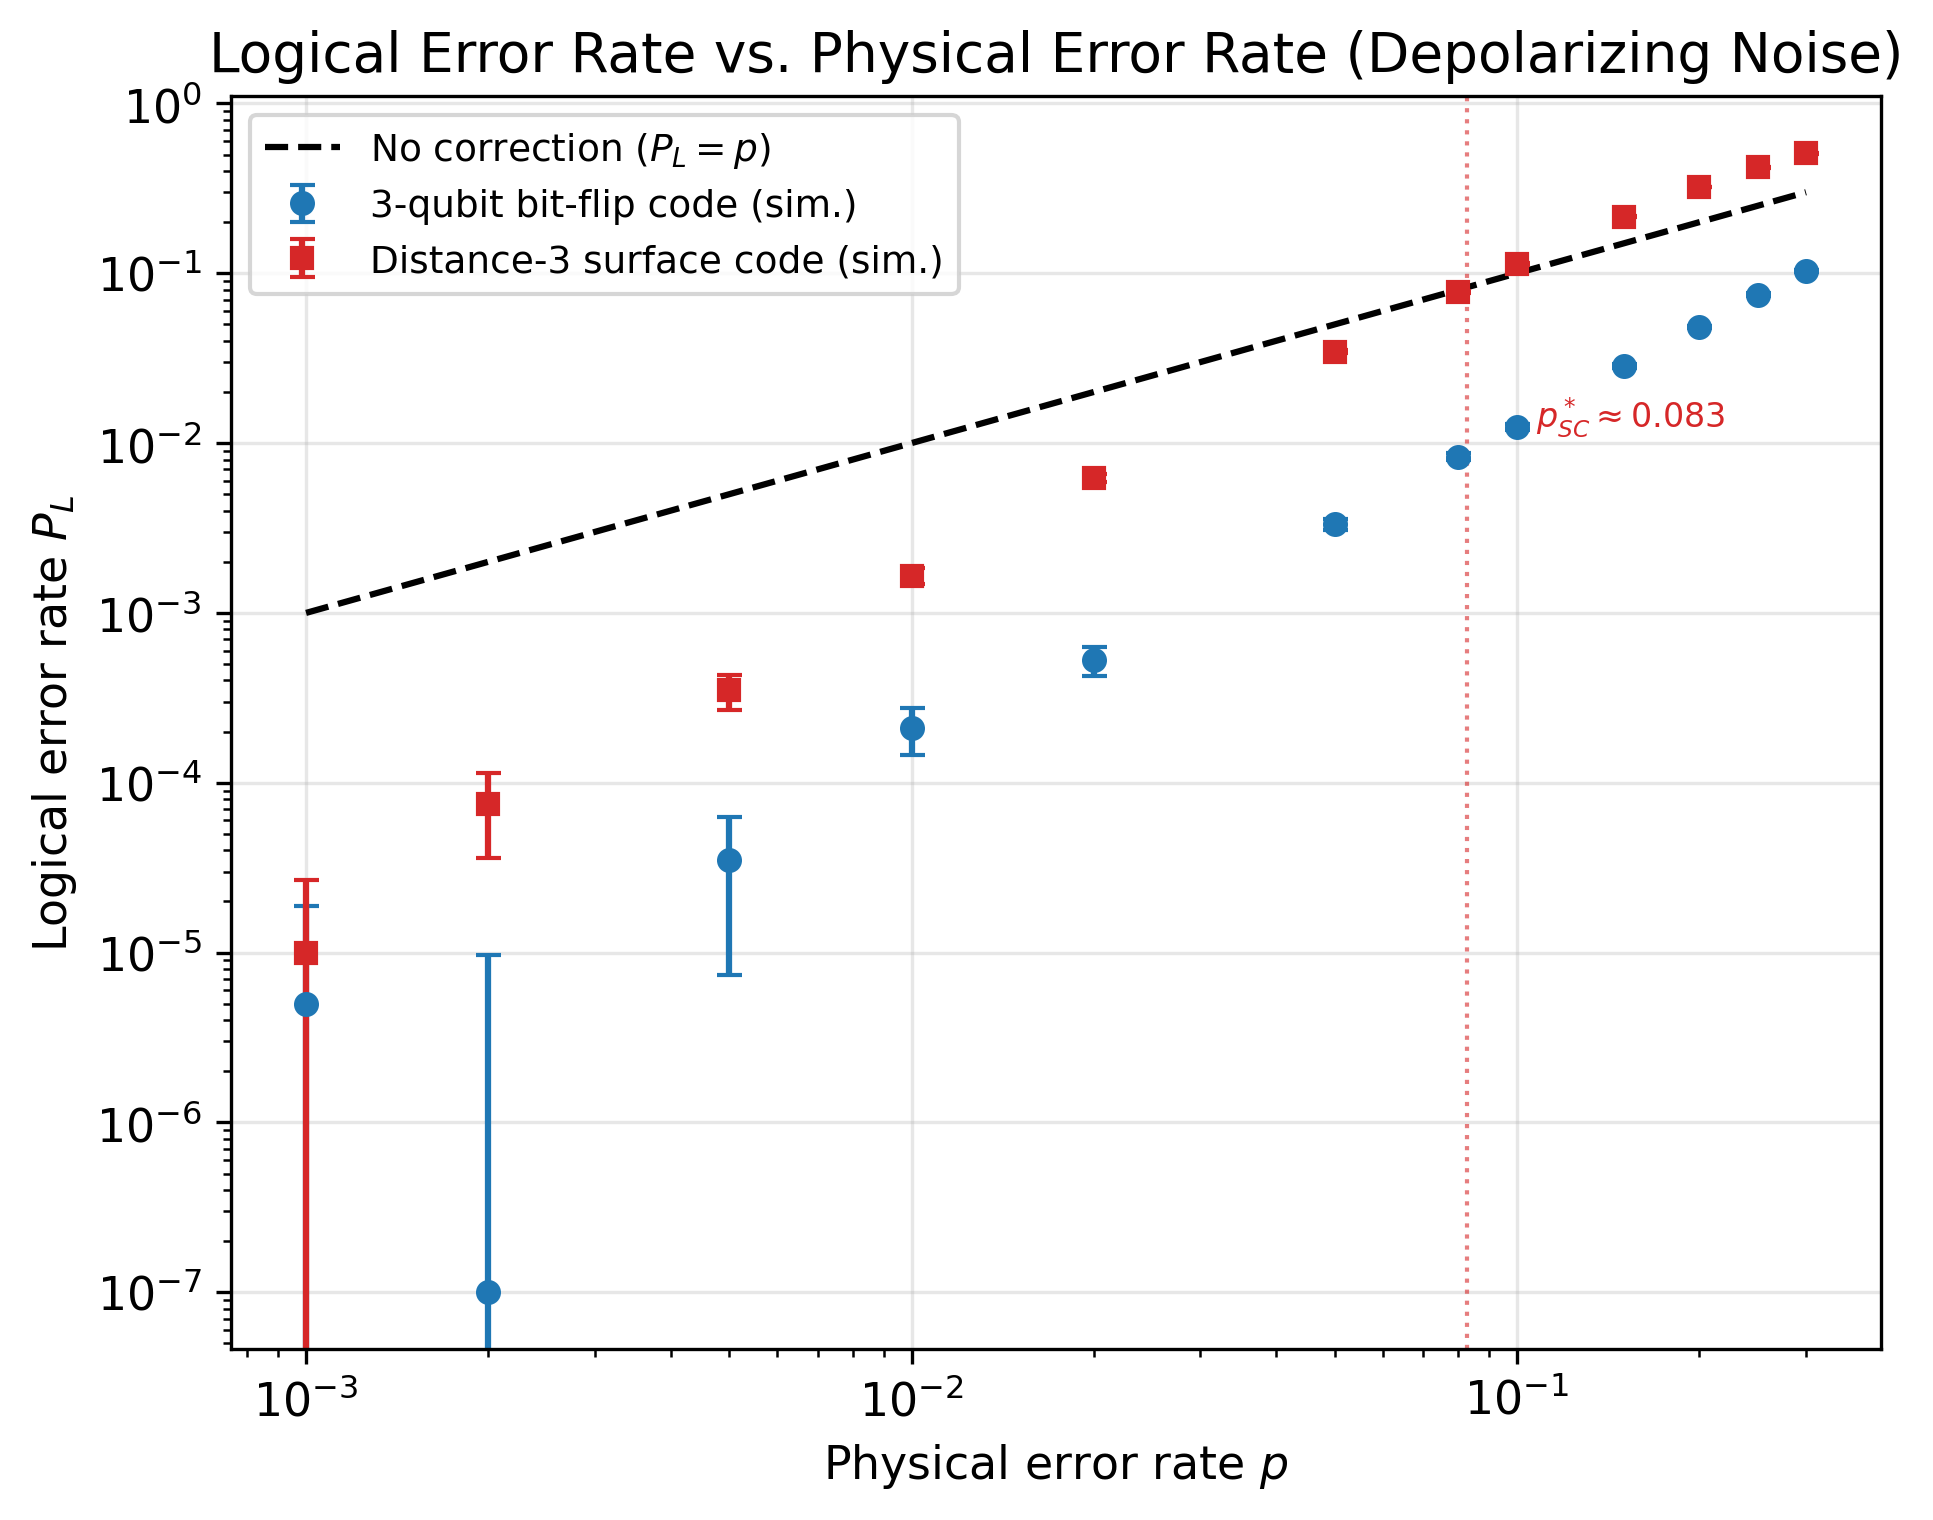

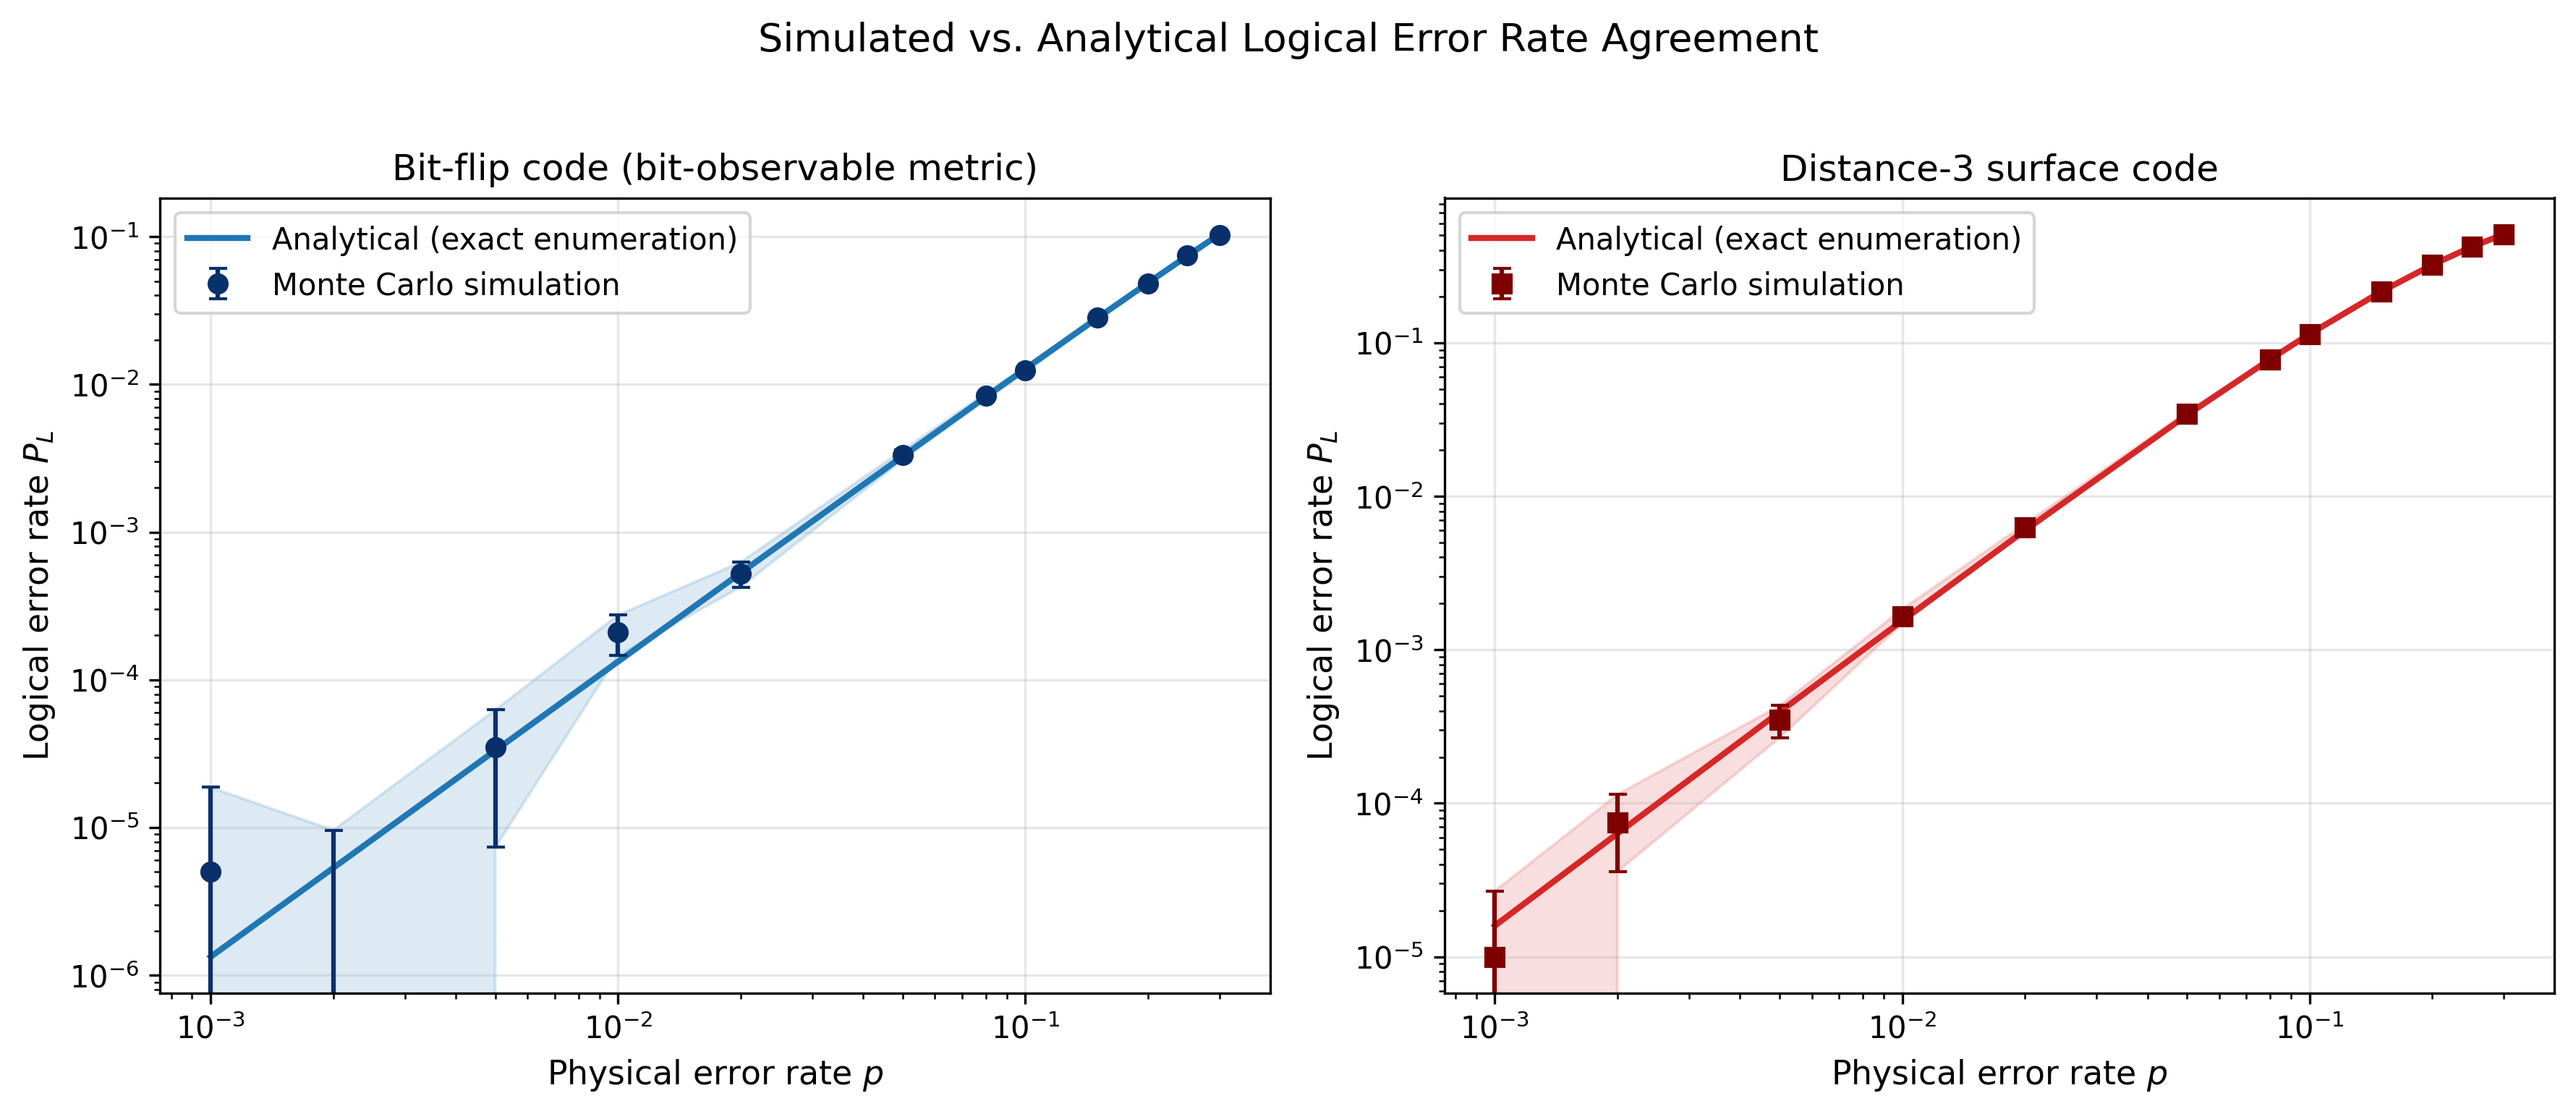

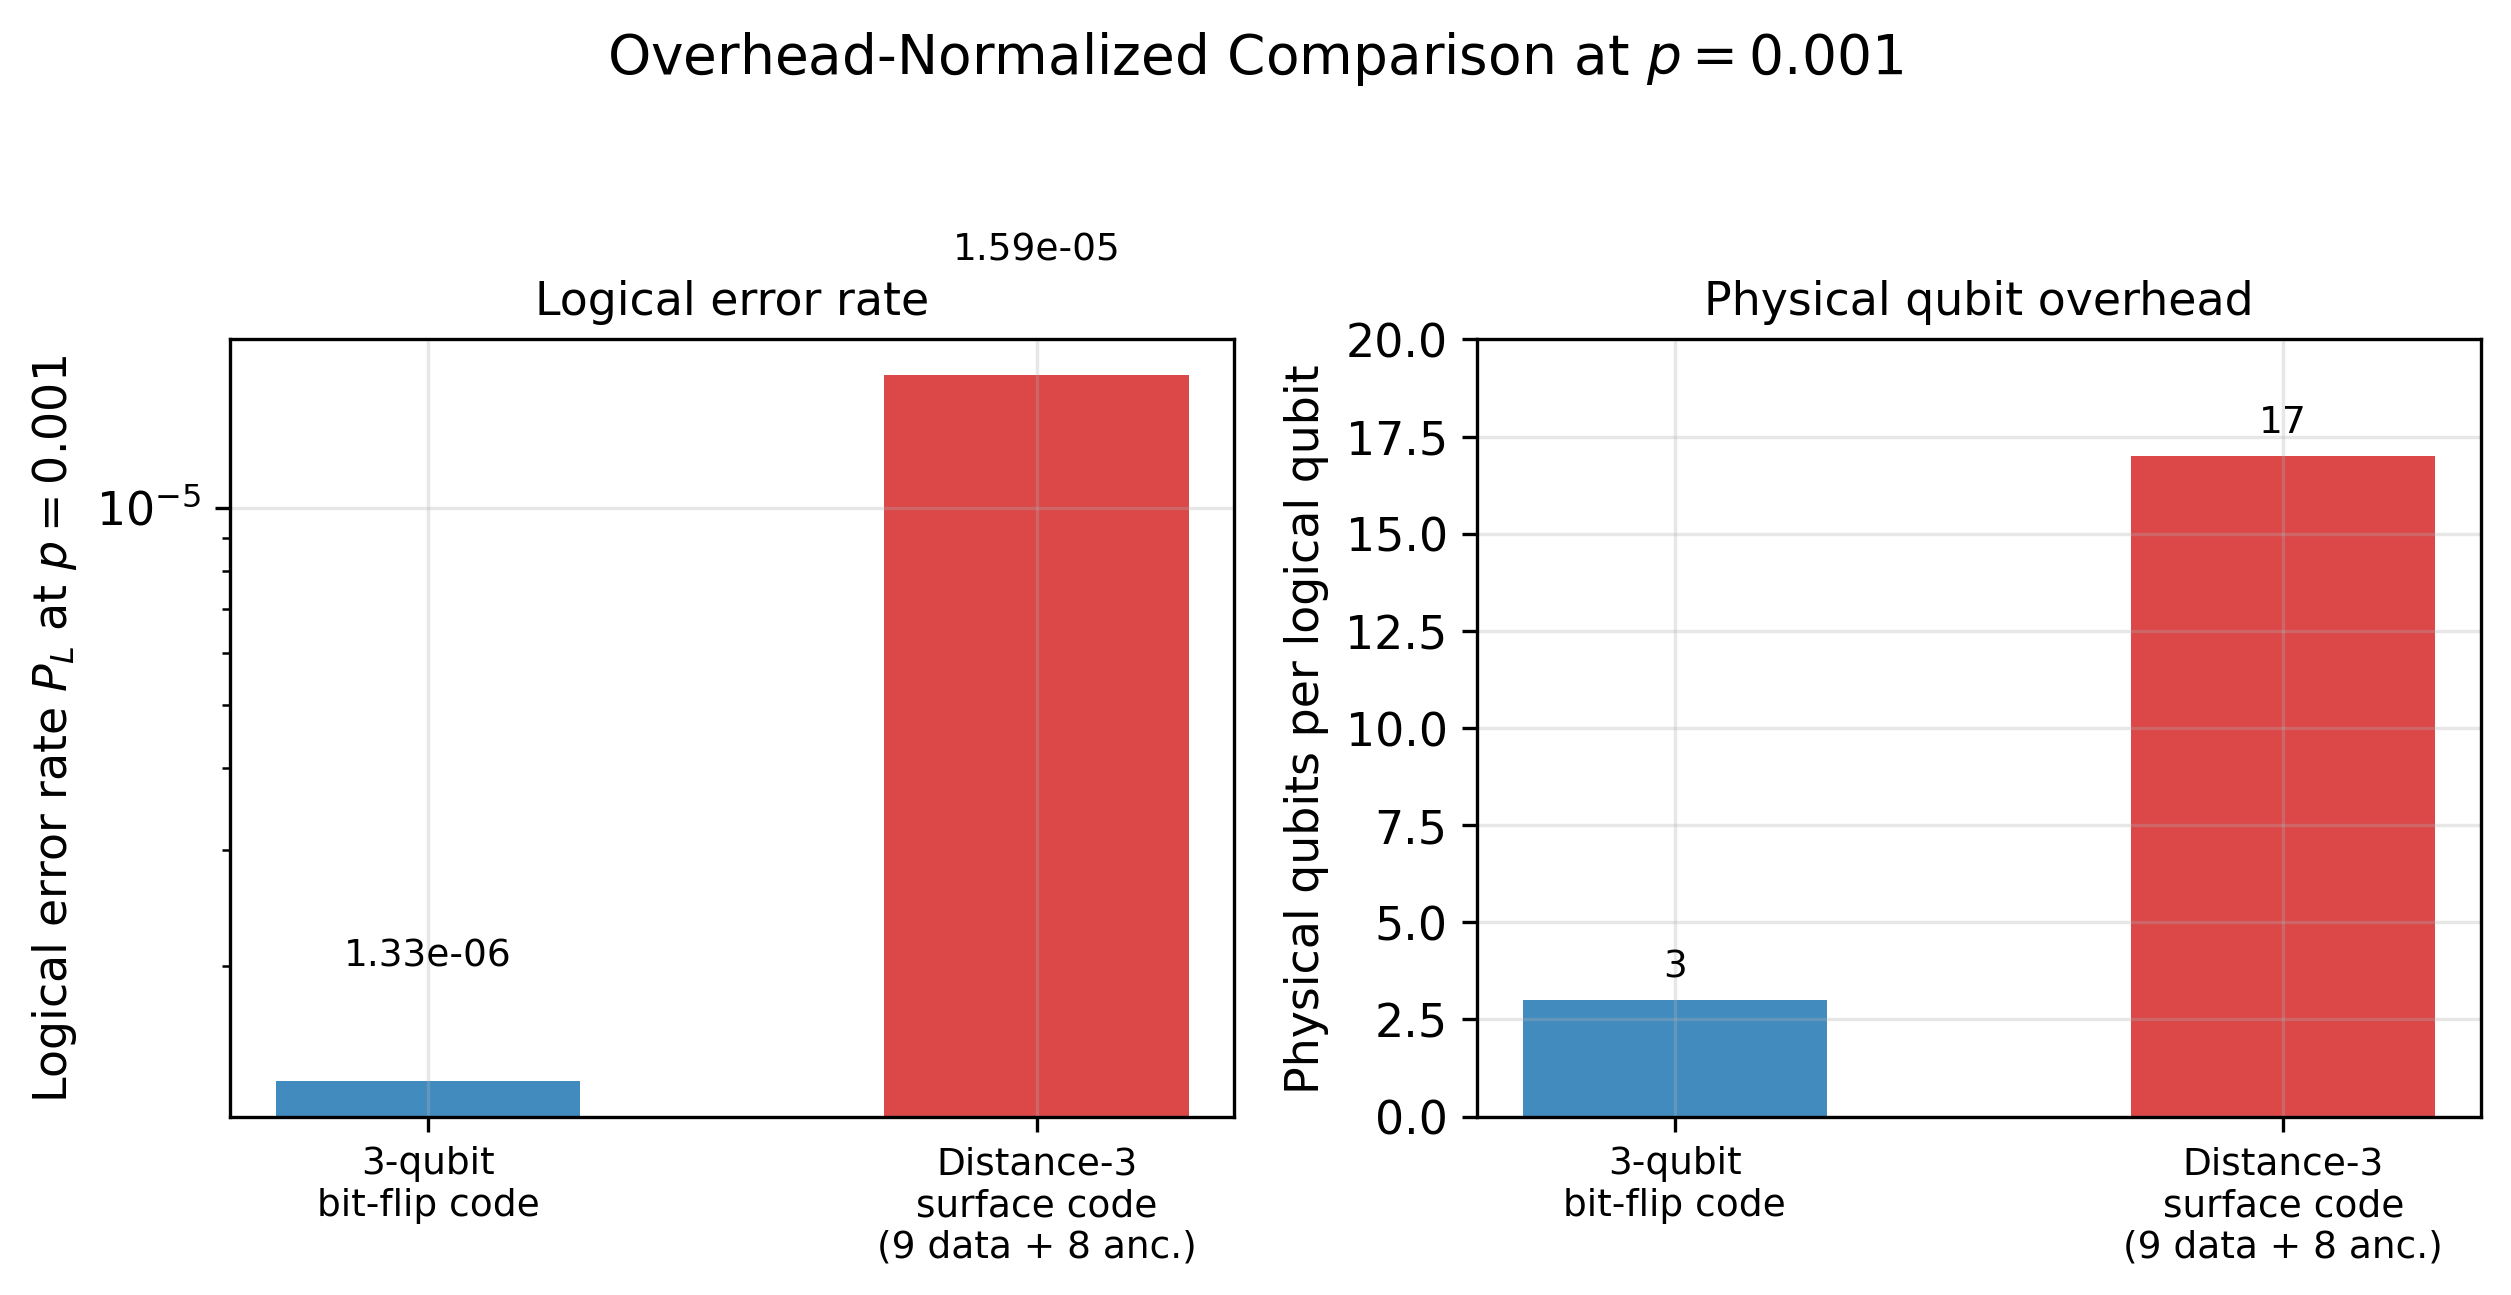

In [4]:
from IPython.display import Image, display
for f in ['fig1_logical_error_vs_physical.png', 'fig2_sim_vs_analytical.png', 'fig3_overhead_comparison.png']:
    display(Image(filename=f))

## Result summary

| Code | Metric | Simulated / exact p\* |
|---|---|---|
| 3-qubit bit-flip | bit-observable | no crossing in (0,1) — unconditionally beneficial |
| 3-qubit bit-flip | full quantum-state protection | ≈ 0.75 (physically irrelevant) |
| Distance-3 surface code | — | ≈ 0.0828 (8.28%) |

Raw per-point results are saved to `results.json` / `data/sweep_results.csv`, and the three figures to `fig1_logical_error_vs_physical.png`, `fig2_sim_vs_analytical.png`, `fig3_overhead_comparison.png`.